In [49]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
import statsmodels.api as sm
import statsmodels.formula.api as smf
from pathlib import Path
from sklearn.preprocessing import StandardScaler


In [50]:
df=pd.read_csv('data/df_limpio.csv')
df.head()


,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,Soltero,1.0,1.0,Vivienda,0.0,0,65.85
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,Casado,1.0,1.0,Vivienda,0.0,0,260.60
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,1.0,0,221.02
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,Casado,0.0,1.0,Vivienda,0.0,0,125.00
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,Soltero,0.0,1.0,Vivienda,0.0,0,800.00


In [51]:
df.describe()

,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Posesion_Hipoteca,Personas_Cargo,Fiador,Impago,Prima
count,101899.000000,101899.000000,101899.0000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000,101899.000000
mean,39.665728,41502.751784,45009.4313,692.305322,212.913925,1.998126,10.670148,37.251133,0.321384,0.351835,0.449096,0.298661,0.115114,384.712288
std,10.103243,16033.982121,46628.3117,87.517421,151.096147,0.998255,3.797937,14.155286,0.181192,0.477541,0.497402,0.457671,0.319161,267.145901
min,19.000000,16000.000000,3000.0000,398.000000,0.000000,1.000000,2.010000,12.000000,0.100000,0.000000,0.000000,0.000000,0.000000,10.000000
25%,33.000000,30468.000000,14995.0000,636.000000,69.000000,1.000000,7.960000,24.000000,0.140000,0.000000,0.000000,0.000000,0.000000,137.470000
50%,40.000000,39082.000000,40000.0000,704.000000,208.000000,2.000000,10.600000,36.000000,0.290000,0.000000,0.000000,0.000000,0.000000,336.280000
75%,46.000000,50136.000000,47398.0000,761.000000,337.000000,3.000000,13.260000,48.000000,0.550000,1.000000,1.000000,1.000000,0.000000,610.695000
max,64.000000,120000.000000,400000.0000,845.000000,628.000000,4.000000,24.440000,60.000000,0.550000,1.000000,1.000000,1.000000,1.000000,800.000000


In [52]:
copy=df.copy()
# hacemos copia por si acaso queremos ver la forma original en algun momento

In [53]:
copy.dtypes

ID                       object
Edad                      int64
Ingresos                float64
Monto_Inicial             int64
Scoring_Crediticio        int64
Meses_Empleo            float64
Num_Creditos              int64
Ratio_Interes           float64
Duracion                float64
Ratio_Deuda_Ingresos    float64
Estudios                 object
Tipo_Jornada_Laboral     object
Estado_Civil             object
Posesion_Hipoteca       float64
Personas_Cargo          float64
Proposito                object
Fiador                  float64
Impago                    int64
Prima                   float64
dtype: object

In [54]:
copy["Tipo_Jornada_Laboral"].unique()

array(['Desempleado', 'Jornada completa', 'Tiempo parcial', 'Autónomo'],
      dtype=object)

In [55]:
copy["Estado_Civil"].unique()

array(['Soltero', 'Casado', 'Divorciado'], dtype=object)

In [56]:
copy["Estudios"].unique()

array(['Escolar', 'Máster', 'Grado Universitario', 'Doctorado'],
      dtype=object)

MODELO: regresión logística ya que tenemos valores binarios (0: no impago, 1: impago)

In [57]:
# variables en escalas muy diferentes, asi que escalar. 
# variables no numéricas--> pasar a numérico (probar si una tiene mas peso que otra y usar ordinal enc, si no one hot)

In [58]:
num=copy.drop(columns=["Estudios", "Tipo_Jornada_Laboral", "Estado_Civil","ID","Proposito"])

<Axes: >

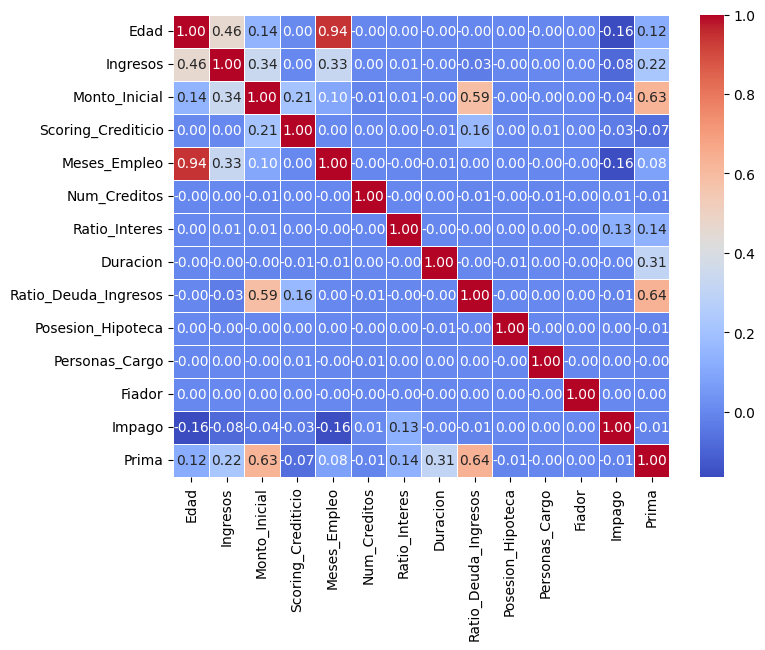

In [59]:
matriz_corr =num.corr(numeric_only=True)

# Crear la figura
plt.figure(figsize=(8, 6))

# Dibujar el mapa de calor
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

Las correlaciones lineales con nuestra variable objetivo `Impago` son en general débiles. Las más relevantes son `Edad` (0,16) y `Meses_Empleo` (0,16), que indican que a más edad y más antigüedad laboral hay menos impagos, y con `Ratio_Interes` (0,13), donde a mayor interés hay más impagos. El resto de variables tienen una correlación bastante baja.

In [60]:
copy.groupby("Estado_Civil")["Impago"].mean()

Estado_Civil
Casado        0.098282
Divorciado    0.077275
Soltero       0.167024
Name: Impago, dtype: float64

In [61]:
copy["Estado_Civil"].value_counts()

Estado_Civil
Casado        52146
Soltero       30756
Divorciado    18997
Name: count, dtype: int64

In [62]:
copy.groupby("Tipo_Jornada_Laboral")["Impago"].mean()  #aqui no existe una jerarquia

Tipo_Jornada_Laboral
Autónomo            0.118491
Desempleado         0.118453
Jornada completa    0.114570
Tiempo parcial      0.112467
Name: Impago, dtype: float64

In [63]:
copy.groupby("Estudios")["Impago"].mean()

Estudios
Doctorado              0.117589
Escolar                0.102644
Grado Universitario    0.124974
Máster                 0.121298
Name: Impago, dtype: float64

In [64]:
# en estudios y jornada no tiene sentido poner un orden, la tasa de impago es muy parecida

Se le da en la columna de `Estado_Civil` a cada categoría un valor desde la menos probabilidad (divorciado) de impago a la que más (soltero), por lo que el estado de esta variable si que afecta al nivel de riesgo

In [65]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc=OrdinalEncoder(categories=[["Divorciado", "Casado", "Soltero"]])

copy[["Estado_Civil"]] = ordinal_enc.fit_transform(copy[["Estado_Civil"]])

In [66]:
copy  #df con el ordinal encoder hecho.

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,Estudios,Tipo_Jornada_Laboral,Estado_Civil,Posesion_Hipoteca,Personas_Cargo,Proposito,Fiador,Impago,Prima
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,Escolar,Desempleado,2.0,1.0,1.0,Vivienda,0.0,0,65.85
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,Máster,Jornada completa,1.0,1.0,1.0,Vivienda,0.0,0,260.60
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,1.0,0,221.02
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,0.0,0,125.00
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,Escolar,Jornada completa,2.0,0.0,1.0,Vivienda,0.0,0,800.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101894,5PM51H,29,35671.0,5681,628,27.0,2,12.11,48.0,0.10,Grado Universitario,Jornada completa,2.0,0.0,1.0,Vivienda,1.0,0,116.89
101895,L0RUJT,28,22864.0,40000,752,9.0,2,10.77,48.0,0.55,Grado Universitario,Jornada completa,1.0,0.0,1.0,Vivienda,0.0,0,607.55
101896,8OJZU0,35,69159.0,41795,699,65.0,2,10.41,36.0,0.29,Doctorado,Tiempo parcial,2.0,0.0,0.0,Vivienda,0.0,0,406.82
101897,II8B24,39,68375.0,21847,722,170.0,2,6.26,36.0,0.14,Máster,Jornada completa,1.0,0.0,1.0,Vivienda,1.0,0,125.32


Usamos **one-hot** en las dos columnas restantes categóricas porque el ordinal solo es adecuado cuando el orden de las categorías repercute en el impago, como ocurría en `Estado_Civil` . En `Estudios` las variables podrían tener un orden, pero a la columna impago no le influye especialmente (Escolar 10,3 %, Doctorado 11,8 %, Máster 12,1 %, Grado 12,5 %), y en `Tipo_Jornada_Laboral` no hay ningún orden, aunque podría ser que al trabajar durante más horas pudiera solventar un pago más rápido con este dataset no es el caso. Por tanto con one-hot cada categoría tiene su propio efecto sin imponer una jerarquía, que es lo que nos interesa.

In [67]:
# las otras dos categóricas, con one-hot
copy = pd.get_dummies(copy, columns=["Estudios", "Tipo_Jornada_Laboral"], dtype=int)

# quitamos una columna por variable (grupo de referencia) para evitar redundancia/multicolinealidad
copy = copy.drop(columns=["Estudios_Escolar", "Tipo_Jornada_Laboral_Jornada completa"])

copy.head()

,ID,Edad,Ingresos,Monto_Inicial,Scoring_Crediticio,Meses_Empleo,Num_Creditos,Ratio_Interes,Duracion,Ratio_Deuda_Ingresos,...,Proposito,Fiador,Impago,Prima,Estudios_Doctorado,Estudios_Grado Universitario,Estudios_Máster,Tipo_Jornada_Laboral_Autónomo,Tipo_Jornada_Laboral_Desempleado,Tipo_Jornada_Laboral_Tiempo parcial
0,6B4H6E,22,16000.0,10000,769,22.0,1,8.96,48.0,0.32,...,Vivienda,0.0,0,65.85,0,0,0,0,1,0
1,VKTUXP,33,38308.0,16474,699,70.0,3,14.07,36.0,0.20,...,Vivienda,0.0,0,260.60,0,0,1,0,0,0
2,5P9OVL,51,51271.0,40770,812,309.0,1,12.66,12.0,0.36,...,Vivienda,1.0,0,221.02,0,1,0,0,0,0
3,YL0W8G,30,31923.0,36707,813,43.0,1,8.96,24.0,0.32,...,Vivienda,0.0,0,125.00,0,1,0,0,0,0
4,YP8WTV,28,27373.0,86981,765,60.0,2,10.07,48.0,0.55,...,Vivienda,0.0,0,800.00,0,0,0,0,0,0


In [68]:
X = copy.drop(columns=["ID", "Proposito", "Impago"])
y = copy["Impago"]

In [72]:
X.columns

Index(['Edad', 'Ingresos', 'Monto_Inicial', 'Scoring_Crediticio',
       'Meses_Empleo', 'Num_Creditos', 'Ratio_Interes', 'Duracion',
       'Ratio_Deuda_Ingresos', 'Estado_Civil', 'Posesion_Hipoteca',
       'Personas_Cargo', 'Fiador', 'Prima', 'Estudios_Doctorado',
       'Estudios_Grado Universitario', 'Estudios_Máster',
       'Tipo_Jornada_Laboral_Autónomo', 'Tipo_Jornada_Laboral_Desempleado',
       'Tipo_Jornada_Laboral_Tiempo parcial'],
      dtype='object')

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y, shuffle=True)
X_train, X_test = X_train.copy(), X_test.copy()

In [70]:
# escalamos las columnas numéricas continuas, (las 0/1 se quedan como están)
cols_num = ["Edad", "Ingresos", "Monto_Inicial", "Scoring_Crediticio", "Meses_Empleo",
            "Num_Creditos", "Ratio_Interes", "Duracion", "Ratio_Deuda_Ingresos", "Prima"]

In [71]:
scaler = StandardScaler()
X_train[cols_num] = scaler.fit_transform(X_train[cols_num])  # aprende media y desviación solo del train
X_test[cols_num] = scaler.transform(X_test[cols_num])        # aplica esos mismos valores al test

Las variables numéricas tienen valores en escalas muy diferentes. Por ejemplo, `Ingresos` puede alcanzar valores de hasta 120.000, mientras que `Ratio_Deuda_Ingresos` tiene valores mucho más pequeños, con un max. de 0,55. Para evitar que estas diferencias afecten al funcionamiento de la regresión logística, estandarizamos las variables numéricas continuas utilizando StandardScaler.

El escalado se realiza utilizando únicamente los datos del conjunto de entrenamiento, para evitar que la información del conjunto de prueba influya en el modelo.